In [1]:
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob
import numpy as np
import yaml
import monai.networks.nets
from tqdm import tqdm
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureType,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityd,
    ScaleIntensityRanged,
    NormalizeIntensity,
    Spacingd,
    Invert,
    Invertd,
    ResizeD,
    Resize,
    LoadImage,
    Rotate,
    Randomizable,
    Transform,
    EnsureType,
)
from monai.handlers.utils import from_engine
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, ThreadDataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
from aim.pytorch import track_gradients_dists, track_params_dists
from matplotlib.widgets import Button, Slider

/opt/anaconda3/envs/Pytorch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


  0%|                                                                                   | 0/8 [00:00<?, ?it/s]

2024-11-11 15:59:46,143 INFO image_writer.py:197 - writing: out/cropped filtered_Hoxb13_HOXDB_E185_male_control_homozygote_3b22b8b8c45e204e300a45f8c6a1a28b_LH/cropped filtered_Hoxb13_HOXDB_E185_male_control_homozygote_3b22b8b8c45e204e300a45f8c6a1a28b_LH_seg.nii.gz


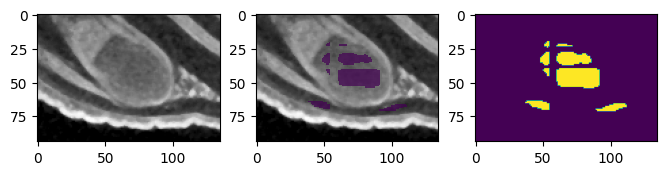

 12%|█████████▍                                                                 | 1/8 [00:04<00:30,  4.38s/it]

2024-11-11 15:59:46,815 INFO image_writer.py:197 - writing: out/cropped filtered_Hoxb13_HOXDB_E185_male_control_homozygote_3b22b8b8c45e204e300a45f8c6a1a28b_RH/cropped filtered_Hoxb13_HOXDB_E185_male_control_homozygote_3b22b8b8c45e204e300a45f8c6a1a28b_RH_seg.nii.gz


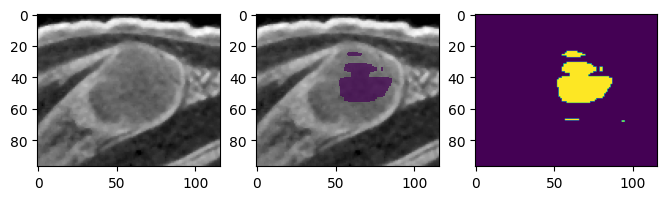

 25%|██████████████████▊                                                        | 2/8 [00:05<00:13,  2.19s/it]

2024-11-11 15:59:47,534 INFO image_writer.py:197 - writing: out/cropped filtered_Kcnj13_KCNHB_E185_female_experimental_homozygote_3a364a4b9fc32ffd3455d9bcb69646f1_LH/cropped filtered_Kcnj13_KCNHB_E185_female_experimental_homozygote_3a364a4b9fc32ffd3455d9bcb69646f1_LH_seg.nii.gz


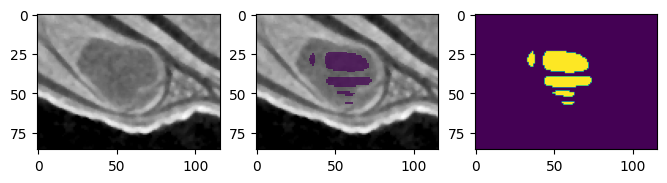

 38%|████████████████████████████▏                                              | 3/8 [00:05<00:07,  1.51s/it]

2024-11-11 15:59:48,138 INFO image_writer.py:197 - writing: out/cropped filtered_Kcnj13_KCNHB_E185_female_experimental_homozygote_3a364a4b9fc32ffd3455d9bcb69646f1_RH/cropped filtered_Kcnj13_KCNHB_E185_female_experimental_homozygote_3a364a4b9fc32ffd3455d9bcb69646f1_RH_seg.nii.gz


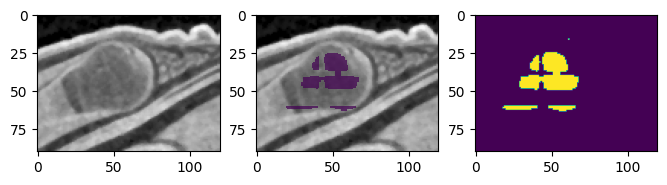

 50%|█████████████████████████████████████▌                                     | 4/8 [00:06<00:04,  1.15s/it]

2024-11-11 15:59:48,879 INFO image_writer.py:197 - writing: out/cropped filtered_Odad1_CDOFB_E185_female_control_homozygote_671f6a8121231dfb31e88c4b276d8a13_RH/cropped filtered_Odad1_CDOFB_E185_female_control_homozygote_671f6a8121231dfb31e88c4b276d8a13_RH_seg.nii.gz


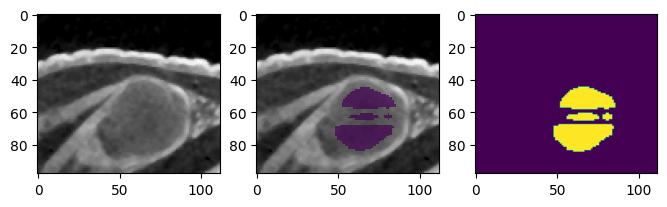

 62%|██████████████████████████████████████████████▉                            | 5/8 [00:07<00:03,  1.01s/it]

2024-11-11 15:59:49,707 INFO image_writer.py:197 - writing: out/cropped filtered_Patl1_PATTB_E185_male_control_homozygote_26438682f1739e328099bcfb857ac527_RH/cropped filtered_Patl1_PATTB_E185_male_control_homozygote_26438682f1739e328099bcfb857ac527_RH_seg.nii.gz


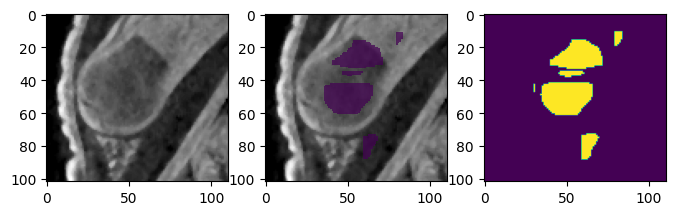

 75%|████████████████████████████████████████████████████████▎                  | 6/8 [00:07<00:01,  1.05it/s]

2024-11-11 15:59:50,513 INFO image_writer.py:197 - writing: out/cropped filtered_Piezo2_JR33628_E185_female_experimental_homozygote_b39ed7b3915b9080745cc8df9028b938_RH/cropped filtered_Piezo2_JR33628_E185_female_experimental_homozygote_b39ed7b3915b9080745cc8df9028b938_RH_seg.nii.gz


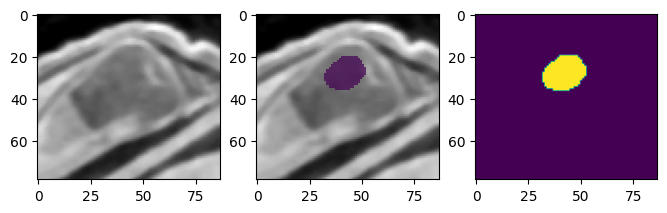

 88%|█████████████████████████████████████████████████████████████████▋         | 7/8 [00:08<00:00,  1.12it/s]

2024-11-11 15:59:51,523 INFO image_writer.py:197 - writing: out/cropped filtered_Zfp414_ZFFFB_E185_female_experimental_homozygote_caa1a267f966579f6dc671d00fe2ab9d_RH/cropped filtered_Zfp414_ZFFFB_E185_female_experimental_homozygote_caa1a267f966579f6dc671d00fe2ab9d_RH_seg.nii.gz


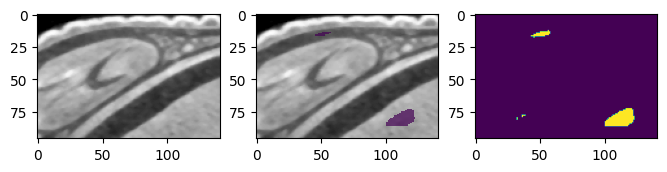

100%|███████████████████████████████████████████████████████████████████████████| 8/8 [00:27<00:00,  3.49s/it]


In [13]:
### USER INPUT REQUIRED ###
# Root path to where the data is located
DATA_DIR = "/Users/adnanzai/Downloads/monai-train/sample"
MODEL_NAME = "/Users/adnanzai/Downloads/monai-train/out/best_metric_model.pth" # Full path to model pickle file, including name. ex: /home/usr/model.pth
MODEL_CONFIG_FILE = "/Users/adnanzai/Downloads/monai-train/example/model_unet.yaml" # Full path to model configuration file, This could be the example/model_*.yaml or example/optuna_config.yaml
###
set_determinism(seed=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
with open(MODEL_CONFIG_FILE, 'r') as stream:
    config = yaml.safe_load(stream)

model_type = config['model']['type']
model = getattr(monai.networks.nets, model_type)(**config['model']['architecture'])

# Load model weights with CPU/GPU compatibility
model.load_state_dict(torch.load(MODEL_NAME, map_location=device))
model.to(device)
model.eval()  # Set the model to evaluation mode


# Automatically locates the 'imagesTs' folder
test_images = sorted(glob.glob(os.path.join(DATA_DIR, "imagesTs", "*.nii.gz")))
test_data = [{"image": image} for image in test_images]

test_org_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        ResizeD(keys="image", spatial_size=config['model']['image_size']),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.0, 2.0, 2.0), mode="bilinear"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image"], source_key="image"),
    ]
)
"""
test_org_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        ResizeD(keys="image", spatial_size=config['model']['image_size']),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.0, 2.0, 2.0), mode="bilinear"),
        CropForegroundd(keys=["image"], source_key="image"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        #ScaleIntensityd(keys=["image"], minv=0, maxv=256),
        EnsureType()
    ]
)
post_transforms = Compose(
    [
        EnsureType(),
        Invertd(
            keys="pred",
            transform=test_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=True,
            to_tensor=True,
        ),
        SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
    ]
)
"""
post_transforms = Compose(
    [
        EnsureType(),
        Invertd(
            keys="pred",
            transform=test_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
        ),
        AsDiscreted(keys="pred", argmax=True, to_onehot=2),
        SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
    ]
)

# Loads data into the data loader
test_org_ds = Dataset(data=test_data, transform=test_org_transforms)
test_org_loader = ThreadDataLoader(test_org_ds, batch_size=1, num_workers=4)
loader = LoadImage()

with torch.no_grad():
    for test_data in tqdm(test_org_loader):
        test_inputs = test_data["image"].to(device)
        roi_size = 40 # Adjustable parameter to present overall image dimensions
        sw_batch_size = 4
        slice = 40 # Adjustable parameter (slice to visualize in the plots). Note inference is performed on the entire 3D dataset.
        test_data["pred"] = sliding_window_inference(test_inputs, roi_size, sw_batch_size, model)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]

        test_output = from_engine(["pred"])(test_data)

        original_image = loader(test_output[0].meta["filename_or_obj"])

        plt.figure("check", (8,8))
        plt.subplot(1,3,1)
        plt.imshow(original_image[:, :, slice], cmap="gray")

        mask_pred = np.zeros(original_image[:, :, slice].shape)
        mask_pred[test_output[0].detach().cpu().numpy()[1, :, :, slice]==1] = 1
        masked_pred = np.ma.masked_where(mask_pred == 0, mask_pred)
        plt.subplot(1, 3, 2)
        plt.imshow(original_image[:, :, slice], cmap="gray")
        plt.imshow(masked_pred, alpha=0.7)

        plt.subplot(1,3,3)
        plt.imshow(test_output[0].detach().cpu().numpy()[1, :, :, slice])

        plt.show()